# DAT550 Final Project

## Music to note transcriptor
________________

# Summary

In this stage all files will be read, transformed and converted to its respective wave file.
Initially substantial features for each wave filewill be extracted and later on saved for ML training.

## Final project objective
To find the most suitable music notation model and evaluate different approaches.

## Data Preprocessing
- To choose among different feature extraction algorithms

## Algorithms to use

- [X] CNN Convolutional Neural Network
- [X] Transformers (From HugginFace)
- [ ] RNN-LSTM (Maybe)
- [ ] Classic classification approach
    - Random Forest
    - Naive Bayes 
 - MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
     - Dataset Splitting
     - MidiSplit(filepath, chunks_per_sec, )
     - MidiLabel(chunk,number_of_tracks ) => Returns a vector with given notes per chunk
     MIDI_FILE [1 Chunk] -> [Wave]  -> Guess the most suitable note [B] 
         - Track 1 - Piano  -> A -> Intensity[1] - Pitch 
         - Track 2 - Drums  -> B -> Intensity [255]
         - TRack 3 - Guitar -> A -> Intensity
     Initial labels -- GroundTruth[] Training outpus 
     
     Feature Extraction - Average -> A
     
 - MIDI to Wave 
 - Wave to Spectrogram [Feature vector]
     - Feature Extraction
 - Test / Train model
 - Output Note per time [Second or millisecond] -> Append to a list
 - [- - - - - - - - - - - - - - - - - - - - - - - A - - - - B - - - - - A A A A A A A A G ]
 - Vector to MIDI
 - MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
 - Evaluation
     - [X] MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
     - [X] MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
 
 - Transform the output of a vector back to MIDI
 
 


# Goal
- [X] Pretrained [Wav2Vec](https://huggingface.co/transformers/model_doc/wav2vec2.html) 
    - Baseline, From a given pretrained model, feed a set of expected features and evaluate its accuracy
- [X] Bootstrap
    - Based on different datasets:
        - MIDI poliphonic Sound files [Training model]
            - Data preprocessing +  CNN - 
        - MIDI poliphonic Sound files [Test model]
        - Complex melodies -- [Test model]
# Training
- Labeling the data - Midi notes extraction
- Song decomposition
- Spectrogram feature extraction
- CNN Model training

To try different Deep learning methods (Neural Network models) to evaluate the most accurate.


# Tasks

### Person 1 [Asahi]
- [x] Create function to open a MIDI File splitted in chunks
- [x] Create function to extract notes per MIDI file
- [ ] Split Spectrogram in time chunks
- [ ] CNN approach
- [ ] Data plotting

### Person 2 [Shaon]

- Model performance evaluation (Loss function)
- Wave2Vec HuggingFace - Transformer Model

### Person 3  [Lucas]
- Classical ML Methods
    - Bayes
    - Clustering
    - Or other

### Person 4 [Tim]
- [X] Create function to Convert MIDI to Wave
- [X] Basic Feature extraction (Wave2Spectrogram)
- Advanced Feature extraction functions
- Plot the number of principal components we use vs the variance of the samples


____________
- [ ]  RNN
- [ ] 
- [ ] Loss Functions




# Initial settings

1.- Download and install FluidSynth Software from 
https://github.com/FluidSynth/fluidsynth/releases/tag/v2.2.0


## Used Datasets
- https://www.kaggle.com/programgeek01/anime-music-midi
- https://www.kaggle.com/soumikrakshit/classical-music-midi

## Other Tools
### FluidSynth
https://github.com/FluidSynth/fluidsynth/releases


In [ ]:
%pip install pretty_midi
%pip install mido
%pip install numpy
%pip install matplotlib
%pip install midi2audio
%pip install tqdm
%pip install --upgrade tensorflow
%pip install librosa
%pip install jupyter_contrib_nbextensions && jupyter contrib nbextension install

## Set Paths and constants
-> Edit to point to the locations on your computer

In [20]:
import os
import numpy as np
import tqdm
import sys

MIDI_SOUND_FONT = 'Soundfont/198_Yamaha_SY1_piano.sf2'

# This path should point to the used midi dataset
data_source_path = os.path.join(os.getcwd(),'data','in','anime')

# This path has to be an existing folder on the disk, otherwise the files will not be created in the following
out_wav_path = os.path.join('data','out','wav')

# Sample rate in Hz, common CD quality is 44100
SAMPLE_RATE = 16000 #44100
MAX_FREQ = 8500  #20000
TEMPO = 1/16
MAX_SAMPLE_SIZE = 5 #sys.maxsize


# Data Preprocessing

Select a series of MIDI files as datasources and convert them into time frames of 87 length size (Standard MIDI number of notes)

## Data Synthesis and Feature extraction

In [21]:
from Utils import Midi
from  Utils import Feature
import importlib
import glob
importlib.reload(Midi)
importlib.reload(Feature)
mid_files_dict = Midi.get_midi_files(data_source_path,max_elements =MAX_SAMPLE_SIZE, tempo = TEMPO, verbose=False)
features = []

for key in tqdm.tqdm(mid_files_dict.keys()):
    try:
        in_file = os.path.join(data_source_path, key)
        out_file = key.replace('.mid', '.wav')
        out_file = os.path.join(out_wav_path, out_file)
        Midi.midi2wave(in_file,out_file, sample_rate=SAMPLE_RATE)
        midi_time = mid_files_dict[key][0]
        midi_data = mid_files_dict[key][1]
        feature = Feature.Feature(midi_time, midi_data, out_file, sample_rate = SAMPLE_RATE,max_freq=MAX_FREQ, verbose=False)
        features.append(feature)
    except (SystemError, FileNotFoundError) as e:
        ## Ignore files whose feature extraction has failed
        print(e)

5it [00:00, 11.32it/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:22<00:00,  4.59s/it]


## Model training
### Creating training/test data and labels 

In [7]:
y = []
X_melspec = []
X_mfcc = []
X_cqt = []

max_len = np.max([len(i) for f in features for i in f.Midi_2_Audio_Time])
for feature in features:
    for index, timeframe in enumerate(feature.Midi_2_Audio_Time):
        y.append(feature.Midi_Notes[index])
        # padding for smaller chunks by duplicating the last slice of a spectrogram
        if len(timeframe) < max_len:
            t = timeframe.copy()
            for i in range(max_len-len(timeframe)):
                t.append(timeframe[-i])
            X_melspec.append(feature.MelSpec[:,t])
            X_mfcc.append(feature.MFCC[:,t])
            X_cqt.append(feature.CQ[:,t])
            
        else:
            X_melspec.append(feature.MelSpec[:,timeframe])
            X_mfcc.append(feature.MFCC[:,timeframe])
            X_cqt.append(feature.CQ[:,timeframe])
y = np.array(y)
X_melspec = np.array(X_melspec)
X_mfcc = np.array(X_mfcc)
X_cqt = np.array(X_cqt)

In [8]:
# split the data in training and test sets
from sklearn.model_selection import train_test_split

TRAIN_SIZE = 0.6
TEST_SIZE = 0.2
VALIDATION_SIZE = 0.2

def train_test_validation_split(X, y):
    X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=TEST_SIZE+VALIDATION_SIZE)
    X_test, X_valid, y_test, y_valid = train_test_split(X_rest, y_rest, test_size=VALIDATION_SIZE/(TEST_SIZE+VALIDATION_SIZE))
    return X_train, X_test, X_valid, y_train, y_test, y_valid
    
X_melspec_train, X_melspec_test, X_melspec_valid, y_melspec_train, y_melspec_test, y_melspec_valid = train_test_validation_split(X_melspec, y)

X_mfcc_train, X_mfcc_test, X_mfcc_valid, y_mfcc_train, y_mfcc_test, y_mfcc_valid = train_test_validation_split(X_mfcc, y)

X_cqt_train, X_cqt_test, X_cqt_valid, y_cqt_train, y_cqt_test, y_cqt_valid = train_test_validation_split(X_cqt, y)

#X_M2A_train, X_M2A_test, X_M2A_valid, y_M2A_train, y_M2A_test, y_M2A_valid = train_test_validation_split(X_M2A, y)


## Save everything in pickle file to skip preprocessing next time

In [9]:
from Utils import Pickle
importlib.reload(Pickle)

In [9]:
Pickle.dump_pickle('mel_spec.pkl',(X_melspec_train, X_melspec_test, X_melspec_valid, y_melspec_train, y_melspec_test, y_melspec_valid))
Pickle.dump_pickle('mfcc.pkl',(X_mfcc_train, X_mfcc_test, X_mfcc_valid, y_mfcc_train, y_mfcc_test, y_mfcc_valid))
Pickle.dump_pickle('cqt.pkl',(X_cqt_train, X_cqt_test, X_cqt_valid, y_cqt_train, y_cqt_test, y_cqt_valid))
#dump_pickle('m2a.pkl',(X_M2A_train, X_M2A_test, X_M2A_valid, y_M2A_train, y_M2A_test, y_M2A_valid))
#dump_pickle('features.pkl',features)

Data\Out\Pickle\mel_spec.pkl
Data\Out\Pickle\mfcc.pkl
Data\Out\Pickle\cqt.pkl


## Load data from pickle file

In [18]:
(X_melspec_train, X_melspec_test, X_melspec_valid, y_melspec_train, y_melspec_test, y_melspec_valid) = Pickle.load_pickle('mel_spec.pkl')
(X_mfcc_train, X_mfcc_test, X_mfcc_valid, y_mfcc_train, y_mfcc_test, y_mfcc_valid) = Pickle.load_pickle('mfcc.pkl')
(X_cqt_train, X_cqt_test, X_cqt_valid, y_cqt_train, y_cqt_test, y_cqt_valid) = Pickle.load_pickle('cqt.pkl')
#(X_M2A_train, X_M2A_test, X_M2A_valid, y_M2A_train, y_M2A_test, y_M2A_valid) = load_pickle('m2a.pkl')
#features = load_pickle('features.pkl')

Data\Out\Pickle\mel_spec.pkl
Data\Out\Pickle\mfcc.pkl
Data\Out\Pickle\cqt.pkl


# Documentation

In [14]:
from matplotlib import pyplot as plt
import librosa.display

Melspectrogram

[Text(0.5, 1.0, 'Normalized log-power Mel-frequency spectrogram')]

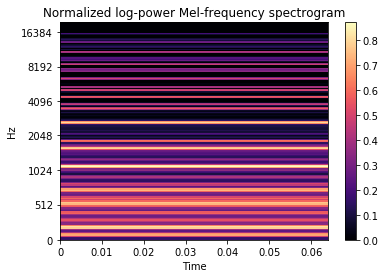

In [15]:
fig, ax = plt.subplots()
img = librosa.display.specshow(X_melspec_train[100], x_axis='time', y_axis='mel', sr=SAMPLE_RATE, fmax=20000, ax=ax)
fig.colorbar(img, ax=ax)
ax.set(title='Normalized log-power Mel-frequency spectrogram')

Mel-frequency cepstral coefficients (MFCCs)

[Text(0.5, 1.0, 'Normalized MFCC')]

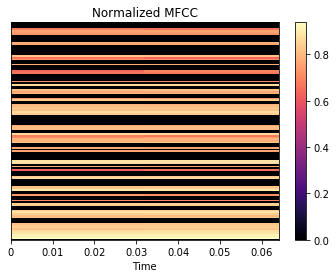

In [16]:
fig, ax = plt.subplots()
img = librosa.display.specshow(X_mfcc_train[100], x_axis='time', sr=SAMPLE_RATE, ax=ax)
fig.colorbar(img, ax=ax)
ax.set(title='Normalized MFCC')

constant-Q transform

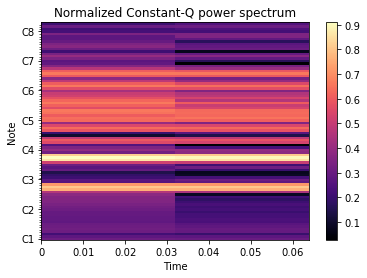

In [17]:
fig, ax = plt.subplots()
img = librosa.display.specshow(X_cqt_train[100], sr=SAMPLE_RATE, x_axis='time', y_axis='cqt_note', ax=ax)
ax.set_title('Normalized Constant-Q power spectrum')
fig.colorbar(img, ax=ax)

### Dimensionality reduction

## PCA

Mel Spectrogram

In [21]:
def num_comp_for_variance(explained_var, variances=[0.9, 0.95, 0.99, 0.999]):
    for var in variances:
        for i, j in enumerate(np.cumsum(explained_var)):
            if j>=var:
                print(i+1, 'components for', '%.2f'%(j*100), 'percent of the variance')
                break

In [22]:
from sklearn.decomposition import PCA
pca = PCA(n_components=256) 
melspec_input_features = [spec.flatten() for spec in X_melspec_train]
pca_ms = pca.fit_transform(melspec_input_features)
ms_explained_var = pca.explained_variance_ratio_
num_comp_for_variance(ms_explained_var)

37 components for 90.29 percent of the variance
65 components for 95.02 percent of the variance
171 components for 99.01 percent of the variance


MFCC

In [16]:
pca = PCA(n_components=256) 
mfcc_input_features = [spec.flatten() for spec in X_mfcc_train]
pca_mfcc = pca.fit_transform(mfcc_input_features)
mfcc_explained_var = pca.explained_variance_ratio_
num_comp_for_variance(mfcc_explained_var)

[0.06014653 0.1069275  0.14864939 0.18585735 0.21904693 0.24864309
 0.27636296 0.30231505 0.32547129 0.34734386 0.36781284 0.3849368
 0.40078442 0.41573878 0.43000012 0.44341879 0.45577309 0.46760214
 0.47889249 0.48984548 0.50058845 0.5112578  0.52149119 0.5315784
 0.54122734 0.5506221  0.55972575 0.56848304 0.57704586 0.58537079
 0.59367897 0.60144951 0.60919757 0.61655448 0.6237494  0.63079199
 0.63765549 0.64420481 0.65065798 0.65692144 0.66305746 0.66908908
 0.67504635 0.68088897 0.68657174 0.69222756 0.69772121 0.70310153
 0.70839328 0.71362757 0.71868584 0.72369415 0.72856393 0.7333806
 0.73808975 0.74274142 0.74732352 0.75187857 0.75630945 0.76067571
 0.76500912 0.76922587 0.77334641 0.77742279 0.7813547  0.78518672
 0.78899365 0.79277228 0.79645908 0.80006242 0.8036543  0.80720403
 0.81074697 0.81413581 0.81749595 0.82073025 0.82392103 0.8270531
 0.83012266 0.83313767 0.83611586 0.83898382 0.84182173 0.84461715
 0.84734417 0.85005349 0.85264137 0.85519564 0.85771718 0.86020113

CQT

In [17]:
pca = PCA(n_components=176) 
cqt_input_features = [spec.flatten() for spec in X_cqt_train]
pca_cqt = pca.fit_transform(cqt_input_features)
cqt_explained_var = pca.explained_variance_ratio_
num_comp_for_variance(cqt_explained_var)

[0.4507522  0.55600402 0.60225506 0.63156991 0.65931342 0.68570997
 0.71185975 0.72995702 0.74713434 0.76364917 0.77779001 0.79098717
 0.80386277 0.81611816 0.82801552 0.8395137  0.84984715 0.85890942
 0.86638599 0.87371257 0.87989094 0.88590678 0.89178911 0.89738588
 0.90225177 0.90660113 0.9107522  0.91482911 0.91837105 0.9213924
 0.92437392 0.92710752 0.92974697 0.9322979  0.93475888 0.93700828
 0.93920406 0.94123642 0.94311308 0.9449448  0.94672351 0.94834898
 0.94997068 0.95147705 0.9528966  0.95429313 0.95564985 0.95696421
 0.95820702 0.95941469 0.96053686 0.96162188 0.96266827 0.96368209
 0.96462267 0.96550414 0.96637484 0.96720818 0.96803779 0.96883295
 0.96962364 0.970388   0.97112044 0.97184122 0.97252734 0.97319987
 0.97385508 0.97450135 0.97513542 0.97576413 0.97637509 0.97697265
 0.97753382 0.97809146 0.97863092 0.97916002 0.97968575 0.980199
 0.9807021  0.98119855 0.98166693 0.98212845 0.98256776 0.98300553
 0.98343729 0.98386678 0.98429476 0.98471006 0.98511479 0.9855188

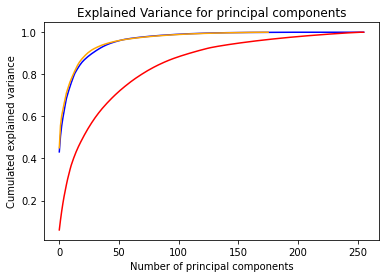

In [18]:
plt.plot(np.cumsum(ms_explained_var), color="blue")
plt.plot(np.cumsum(mfcc_explained_var), color="red")
plt.plot(np.cumsum(cqt_explained_var), color="orange")
plt.xlabel('Number of principal components')
plt.ylabel('Cumulated explained variance')
plt.title('Explained Variance for principal components')
plt.show()

### TSNE

In [19]:
#from sklearn.manifold import TSNE

#tsne_ms = TSNE(n_components=2).fit_transform(pca_ms)
#tsne_mfcc = TSNE(n_components=2).fit_transform(pca_mfcc)
#tsne_cqt = TSNE(n_components=2).fit_transform(pca_cqt)

#tsne_ms.shape, tsne_mfcc.shape, tsne_cqt.shape

((169328, 2), (169328, 2), (169328, 2))

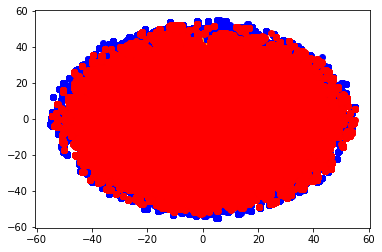

In [20]:
#plt.scatter(tsne_ms.T[0], tsne_ms.T[1], color="blue")
#plt.scatter(tsne_mfcc.T[0], tsne_mfcc.T[1], color="orange")
#plt.scatter(tsne_cqt.T[0], tsne_cqt.T[1], color="red")

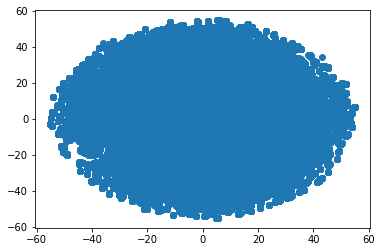

In [21]:
#plt.scatter(tsne_ms.T[0], tsne_ms.T[1])

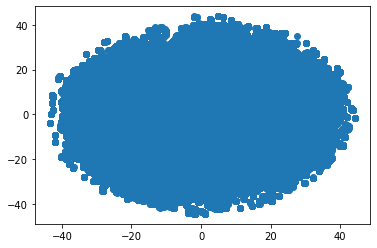

In [22]:
#plt.scatter(tsne_mfcc.T[0], tsne_mfcc.T[1])

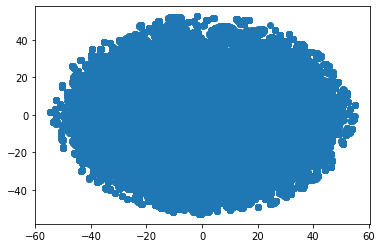

In [23]:
#plt.scatter(tsne_cqt.T[0], tsne_cqt.T[1])

# Training data

## Classical ML Algorithms

In [19]:
import tensorflow as tf

## Deep Learning Algorithms

### Multilayer Perceptron with PCA

In [27]:
pca = PCA(n_components=160) 
train_flattened = np.array([spec.flatten() for spec in X_melspec_train])
X_train = pca.fit_transform(train_flattened)
y_train = np.array(y_melspec_train)

test_flattened = np.array([spec.flatten() for spec in X_melspec_test])
X_test = pca.transform(test_flattened)
y_test = np.array(y_melspec_test)

valid_flattened = np.array([spec.flatten() for spec in X_melspec_valid])
X_valid = pca.transform(valid_flattened)
y_valid = np.array(y_melspec_valid)

In [28]:
input_shape = X_train[0].shape
print(input_shape)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(160, activation='relu'),
    tf.keras.layers.Dense(320, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(320, activation='relu'),
    tf.keras.layers.Dense(160, activation='relu'),
    tf.keras.layers.Dense(88, activation='sigmoid'),
])

model.summary()

(160,)
Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_5 (Dense)              (None, 160)               25760     
_________________________________________________________________
dense_6 (Dense)              (None, 320)               51520     
_________________________________________________________________
dropout_1 (Dropout)          (None, 320)               0         
_________________________________________________________________
dense_7 (Dense)              (None, 320)               102720    
_________________________________________________________________
dense_8 (Dense)              (None, 160)               51360     
_________________________________________________________________
dense_9 (Dense)              (None, 88)                14168     
Total params: 245,528
Trainable params: 245,528
Non-trainable params: 0
_________________________________________

In [29]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
checkpoint_path = "pca_feedfwd/cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 verbose=1)

In [ ]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), callbacks=[cp_callback], epochs=10, batch_size = 128)

Epoch 1/10
1339/1341 [============================>.] - ETA: 0s - loss: 0.1068 - accuracy: 0.0765
Epoch 00001: saving model to pca_feedfwd\cp.ckpt
1341/1341 [==============================] - 7s 5ms/step - loss: 0.1068 - accuracy: 0.0765 - val_loss: 0.1006 - val_accuracy: 0.0989
Epoch 2/10
1339/1341 [============================>.] - ETA: 0s - loss: 0.0967 - accuracy: 0.1011
Epoch 00002: saving model to pca_feedfwd\cp.ckpt
1341/1341 [==============================] - 6s 5ms/step - loss: 0.0967 - accuracy: 0.1011 - val_loss: 0.0960 - val_accuracy: 0.1031
Epoch 3/10
 837/1341 [=================>............] - ETA: 2s - loss: 0.0937 - accuracy: 0.1096

In [ ]:
from  Utils import Evaluation
importlib.reload(Evaluation)
Evaluation.get_confusion_matrix(model(X_valid), y_valid)

## CNN

In [34]:
X_melspec_train[0].

(40, 6)

In [29]:
np.concatenate(X_melspec_train)[0]

array([0.61619246, 0.6086322 , 0.60116524, 0.6026863 , 0.6007153 ,
       0.61619246], dtype=float32)

ParameterError: Unknown axis type: mfcc

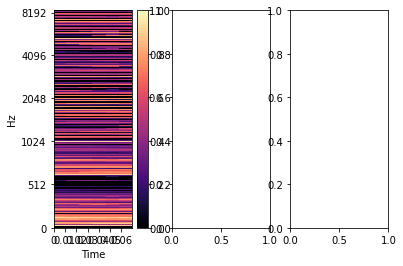

In [45]:
fig, axs = plt.subplots(nrows=1,ncols=3)
fmax = 8500
img = librosa.display.specshow(np.concatenate(X_melspec_train), y_axis='mel',x_axis='time', fmax=fmax,sr = SAMPLE_RATE,ax=axs[0])
fig.colorbar(img, ax=axs[0])
#img = librosa.display.specshow(np.concatenate(X_cqt_train), y_axis='cqt', x_axis='time', fmax=fmax,sr = SAMPLE_RATE,ax=axs[1])
#fig.colorbar(img, ax=axs[1])
img = librosa.display.specshow(np.concatenate(X_mfcc_test), y_axis='mfcc',x_axis='time', fmax=fmax,sr = SAMPLE_RATE,ax=axs[2])
fig.colorbar(img, ax=axs[2])
fig.suptitle(t='Normalized log-power Mel-frequency spectrogram')
fig.x_axis = 'time'
fig.y_axis = 'mel'




c:\python\38\lib\site-packages\librosa\display.py:974: MatplotlibDeprecationWarning: The 'linscaley' parameter of __init__() has been renamed 'linscale' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  scaler(mode, **kwargs)


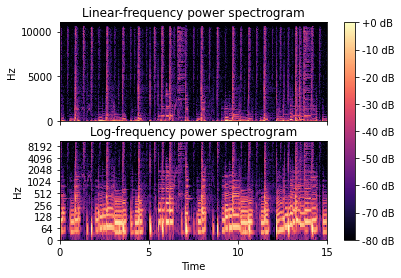

In [134]:
import matplotlib.pyplot as plt
y, sr = librosa.load(librosa.ex('choice'), duration=15)
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
img = librosa.display.specshow(D, y_axis='linear', x_axis='time',
                               sr=sr, ax=ax[0])
ax[0].set(title='Linear-frequency power spectrogram')
ax[0].label_outer()

hop_length = 1024
D = librosa.amplitude_to_db(np.abs(librosa.stft(y, hop_length=hop_length)),
                            ref=np.max)
librosa.display.specshow(D, y_axis='log', sr=sr, hop_length=hop_length,
                         x_axis='time', ax=ax[1])
ax[1].set(title='Log-frequency power spectrogram')
ax[1].label_outer()
fig.colorbar(img, ax=ax, format="%+2.f dB")

In [ ]:
fig, ax = plt.subplots()
img = librosa.display.specshow(X_mfcc_train[100], x_axis='time', sr=SAMPLE_RATE, ax=ax)
fig.colorbar(img, ax=ax)
ax.set(title='Normalized MFCC')

fig, ax = plt.subplots()
img = librosa.display.specshow(X_cqt_train[100], sr=SAMPLE_RATE, x_axis='time', y_axis='cqt_note', ax=ax)
ax.set_title('Normalized Constant-Q power spectrum')
fig.colorbar(img, ax=ax)

## Using Transformers (Speech to Text adapt)

# Results and evaluation